The source codes are in the RVSNUpy directory. To use RVSNUpy, please put it in the working directory.

### Dependency
- astropy

- tqdm

- pandas

- joblib

Those packages must be installed to use RVSNUpy. Please install them using pip or conda. When I distribute the RVSNUpy as a package, this will be installed automatically if a user install the RVSNUpy

In this tutorial, I also use
- numpy
- matplotlib
- glob
- os

# Import pakages

In [4]:
# Import basic packages
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, '../../')
# Import astropy modules



### matplotlib setting

In [5]:
plt.rcParams["font.family"] = 'STIXGeneral' 
plt.rcParams['text.usetex'] = False
plt.rcParams["mathtext.fontset"] = 'cm'
plt.rcParams['font.size']=22
plt.rcParams['axes.linewidth']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.direction']='in'
plt.rcParams['xtick.minor.visible']=True
plt.rcParams['ytick.minor.visible']=True
plt.rcParams['xtick.major.size']=7
plt.rcParams['ytick.major.size']=7
plt.rcParams['xtick.minor.size']=3.5
plt.rcParams['ytick.minor.size']=3.5
plt.rcParams['xtick.major.width']=1
plt.rcParams['ytick.major.width']=1
plt.rcParams['xtick.minor.width']=1
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.right']=True
plt.rcParams['xtick.top']=True

## 1. Read spectrum
In RVSNUpy, all spectrum will be processed in the form of 4xn numpy array. So, you have to prepare the spectra with the following form;
- 1st row: wavelength (float). wavelengths of the pixels in the $\AA$ unit
- 2st row: flux (float).
- 3st row: uncertainty (float). uncertainty of the flux in the same unit with the flux.
- 3st row: mask array(0/1 or True/False). If True, the corresponding flux and uncertainty will be masked when the cross-correlation is performed. 

Below is the example to read a MMT spectra.
* Usually, in a MMT spectra, the region of the wavelength larger than 7500 $\AA$ is unreiable due to reddening of Hectospec 

Text(0.5, 1.0, '300.hectomap_2018a_1532.ms.fits')

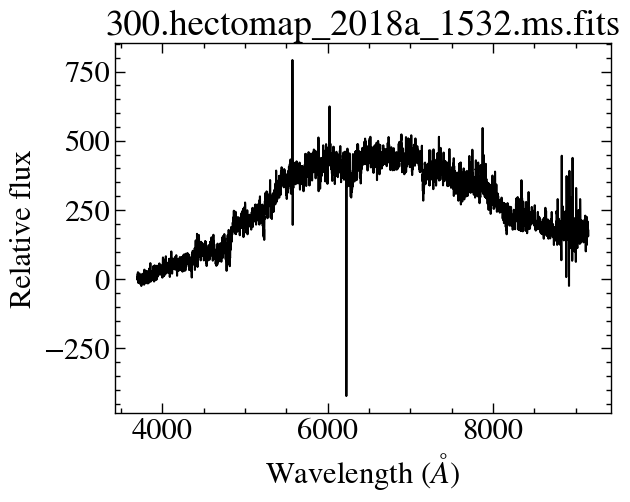

In [6]:
from astropy.io import fits

file = 'spectrum/300.hectomap_2018a_1532.ms.fits'

# read wavelength, flux, and uncertainty data from the fits file
f = fits.open(file)
header = f[0].header
flux = (f[0].data)[0][0]
flux = flux
uncertainty = ((f[0].data)[3][0])

sz = len(flux)
crval = header['CRVAL1']

if 'CDELT1' in header:
    cdelt = header['CDELT1']

else:
    cdelt = header['CD1_1']
    
crpix = header['CRPIX1']
    
wave = (np.arange(sz) - crpix + 1)*cdelt+crval
spectrum = np.vstack([wave, flux, uncertainty])

# plotting
plt.plot(spectrum[0,:], spectrum[1,:], 'k-')
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Relative flux')
plt.title(os.path.basename(file))

Note that the wavelength of the spectra must be in linear scale for filtering in RVSNUpy. If the spectra is given in other scales, such as log scale, you must interpolate them in the linear scale.

In a current version, RVSNUpy provides automated spectra-reading function for a MMT and SDSS spectra.

(The wavelength of the SDSS spectra is based on the vaccum wavelength. But, in redshift measuremnt, the air wavelength are usually used. The template used in the RVSNUpy is also based on the air wavelength, therefore one must change the wavelength if the spectra uses vaccum wavelength. SDSS_fits function of the RVSNUpy automatically changes the wavelength form the vaccum to the air.)

/data1/no.wan/proj_RVSNUpy1.0/RVSNUpy/example/../../RVSNUpy/spectrum_import.py:98: RuntimeWarning: divide by zero encountered in true_divide
  uncertainty = (1/np.sqrt(uncertainty))


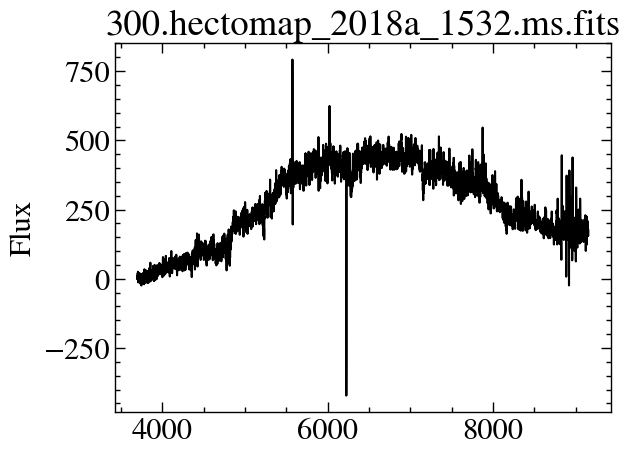

Text(0.5, 1.0, 'spec-1289-52734-0004.fits')

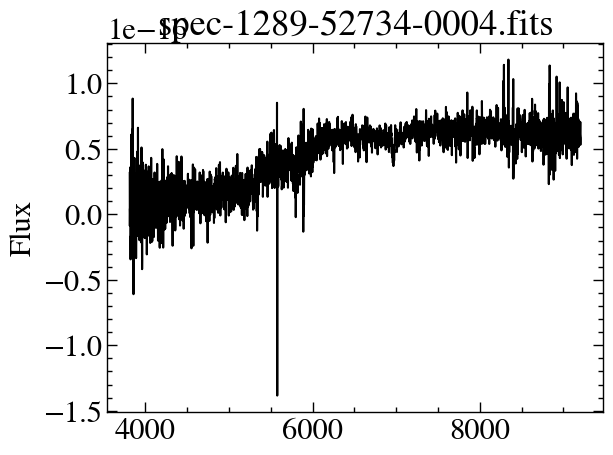

In [10]:
from RVSNUpy.spectrum_import import MMT_raw, sdss_fits

# MMT spectra
file = 'spectrum/300.hectomap_2018a_1532.ms.fits'
spectrum = MMT_raw(file)

# plotting
plt.plot(spectrum[0,:], spectrum[1,:], 'k-')
plt.ylabel('Flux')
plt.title(os.path.basename(file))
plt.show()

# SDSS spectra
file = 'spectrum/spec-1289-52734-0004.fits'
spectrum = sdss_fits(file)
# plotting
plt.plot(spectrum[0,:], spectrum[1,:], 'k-')
plt.ylabel('Flux')
plt.title(os.path.basename(file))

## 2. Measure the redshift of one spectra
Now, we will measure the redshift using the 'rvm' class of thervm modulem

You need to put the spectra and a template set to the rvm. Then 'redshift' function returns the tables of redshift measurment for 5 best template sorted by r-values.

Following templates are prepared at now:
- mmt_template: templates for a MMT spectra
- sdss_star: templates for a SDSS star spectra
- sdss_galaxy: templates for a SDSS galaxy spectra
- sdss_QSO: templates for a SDSS QSO spectra
- sdss_template: templates for all SDSS spectrum
- sdss_temp_wt_qso: templates for SDSS star + galaxy spectrum

For SDSS galaxy, we recommend you to use sdss_temp_wt_qso

In [11]:
from RVSNUpy.spectrum_import import sdss_fits
file = 'spectrum/spec-1289-52734-0004.fits'
spectrum = sdss_fits(file)

from RVSNUpy.template import sdss_temp_wt_qso
from RVSNUpy.rvm import rvm, multi_rvm

measure = rvm(spectrum, sdss_temp_wt_qso)
measure.redshift()

,Template_name,Redshift,r-value,Error,Flag
0,G star1,0.345635,10.511177,0.000114,0
1,F star1,0.345654,10.221698,0.000141,0
2,K star,0.345636,10.039980,0.000116,0
3,G star0,0.345653,9.309463,0.000160,0
4,Luminous Red Galaxy,0.345751,8.806301,0.000171,0
5,Early-type galaxy,0.345703,8.714720,0.000143,0
6,F star0,0.345416,6.399145,0.000194,1
7,Galaxy0,0.345592,5.235569,0.000248,1
8,Galaxy2,0.262812,5.211561,0.000077,1
9,Late-type galaxy,0.262812,5.137407,0.000076,1


You can think of R as a reliability of the measurement. Usually, if R>5, the measurement is reliable.

RVM has other options:
- hcutoff_scale: float, largest feature in the spectrum that are to be removed by high-stop filtering. Default is 10
- apodization window: float, apodization size when rvm process the spectra before the cross-correlation. Default is 0.05 (5%)
- clipping (int): Removes the line whose fluxes are larger than (clipping)*sigma. It can be useful if the spectrum is not flux-calibrated or the sky-lines are not well subtracted.
- spectrum_range: list ([float, float]). The wavelength range to be used in redshift measurement. If none, all range will be used. Default is none
- template_range: list ([float, float]). The wavelength range of the templates to be used in redshift measurement. If none, all range will be used. Default is none
- correlation_range: list ([float, float]). Range of the possible redshifts. Default is [-0.01,2]
- mask: list ([[[float,float],[float,float]]). The wavelength region to be masked during the cross-correlation. If [[lam1, lam2], [lam3,lam4]], lam1~lam2 and lam3~lam4 is maksed. If none, no region will be masked. Default is none.
- continuum_subtraction: bool, If true, the continuum of the spectra is subtracted before the cross-correlation. Defualt is True.
- window: Size of the window that is used in running median when subtracting the continuum. If none, the window is automatically determined. Defulat is none
- sigma: The criterion of the sigma-clipping that is used in running median when subtracting the continuum. Deaulf is 3

Below is the example of measuring redshift with masking some ranges 

In [12]:
badlines = [[4030.0, 4070.0],
            [4333.0, 4383.0],
            [5436.0, 5496.0],
            [5542.0, 5612.0],
            [6275.0, 6325.0],
            [6339.0, 6389.0]] # These are the typical sky lines.


measurement = rvm(spectrum, sdss_temp_wt_qso, mask = badlines, spectrum_range=[4000,8500])
measurement.redshift()


,Template_name,Redshift,r-value,Error,Flag
0,Luminous Red Galaxy,0.345772,10.257147,0.000151,0
1,Early-type galaxy,0.345733,9.792644,0.000129,0
2,G star1,0.345732,9.292070,0.000125,0
3,K star,0.345705,8.896319,0.000124,0
4,F star1,0.345866,8.725363,0.000166,0
5,G star0,0.345604,7.843367,0.000159,1
6,Galaxy2,0.262778,5.997153,0.000074,0
7,Late-type galaxy,0.262800,5.962992,0.000069,0
8,Galaxy1,0.262779,5.700608,0.000080,0
9,F star0,0.345711,5.395554,0.000238,1


If you want to see the correlation signal, use 'cc'. It will returns . It takes an interger or a template name (string) as an input. If integer, say 0, is input, it returns the lags and cross correlation signals of the cross-correlation with the spectra resampled to be cross-correlated of 0th template in the above table. If the template name is input, it reuturns the result corressponding to that template. If plotting=True, it shows the resampled spectrum and the cross-correlation result

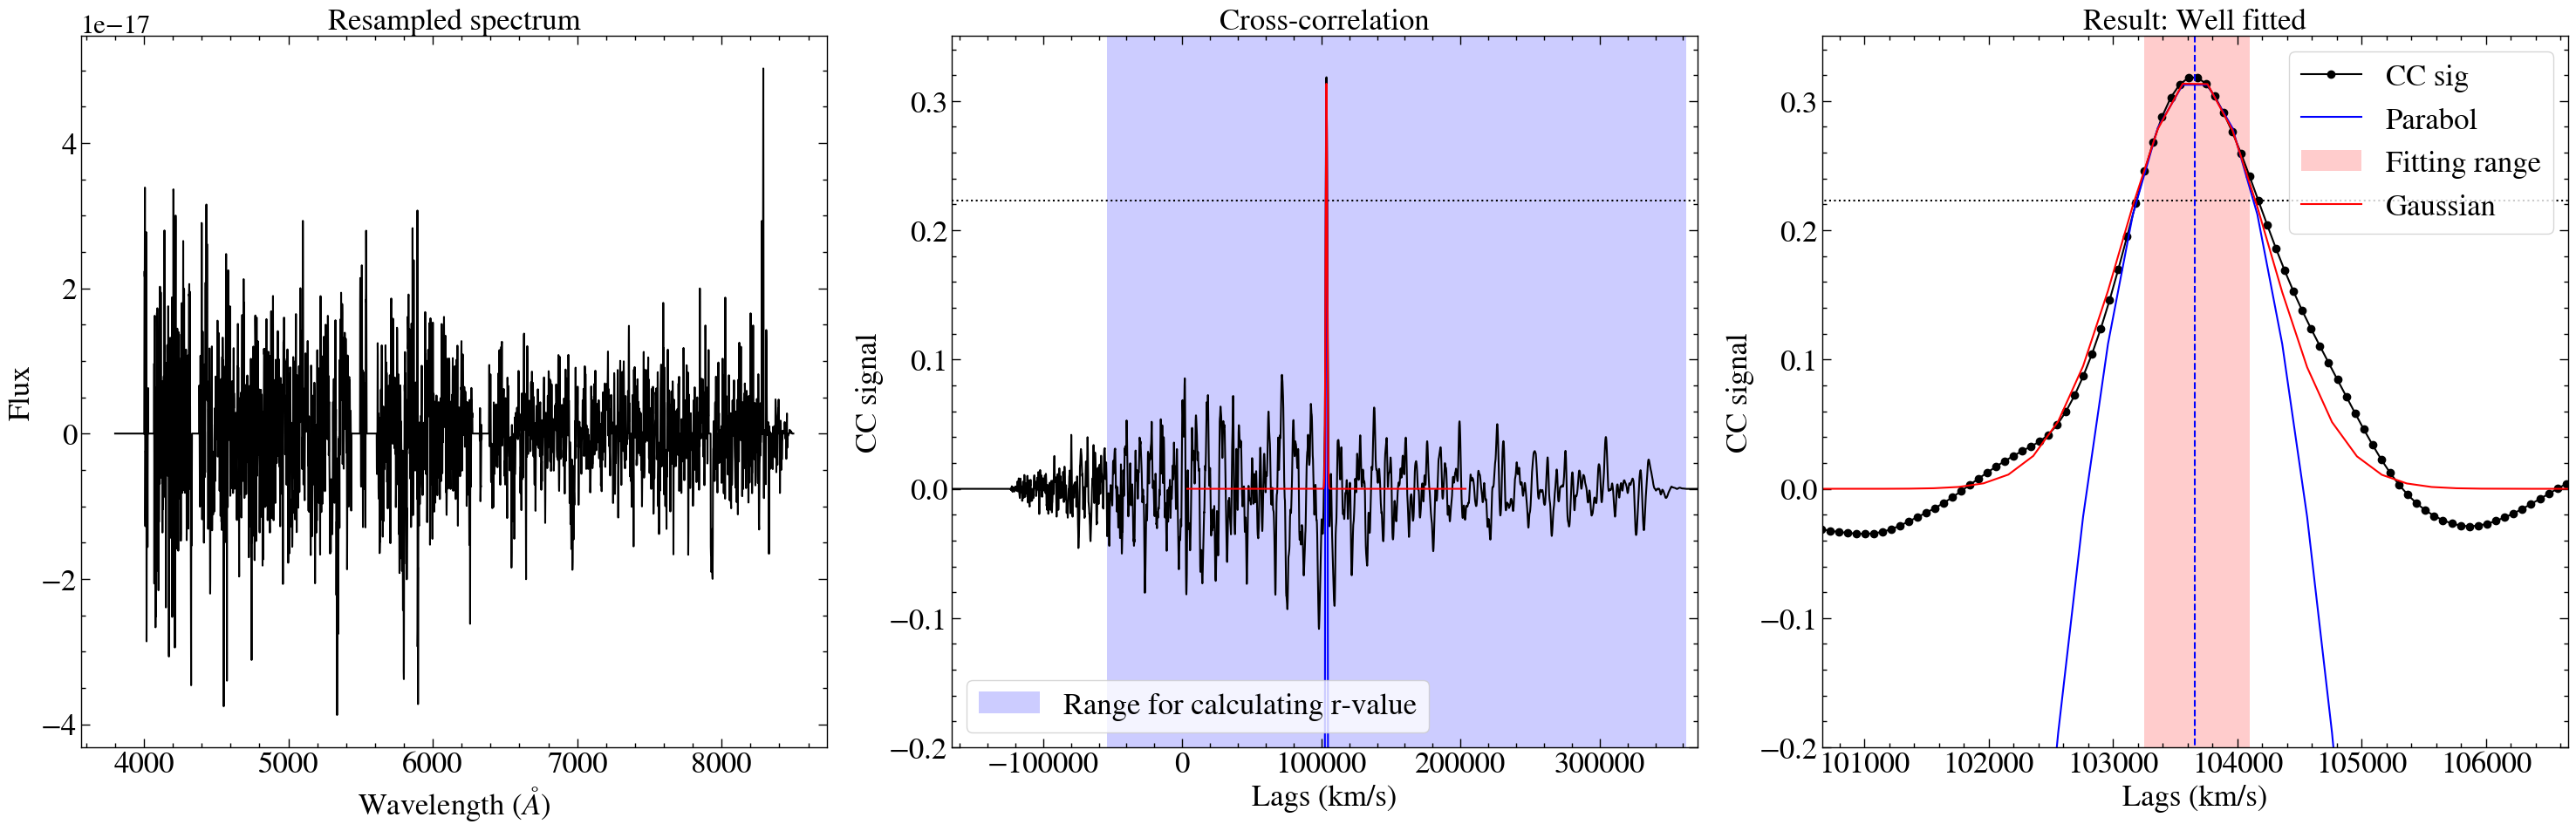

In [13]:
lags, corr, resampled_spectra = measurement.cc(0,plotting=True)

## 3. Measure the multiple redshifts

If you save multiple spectrum in the list, you can measure the redshifts of them simultaneously using multi_rvm function

In [14]:
from RVSNUpy.spectrum_import import sdss_fits
from RVSNUpy.template import sdss_temp_wt_qso, sdss_template_galaxy
from RVSNUpy.rvm import multi_rvm

# save the spectrum in the list
spec_list = []

files, z, zerr = np.loadtxt('spectrum/summary.csv', usecols=[0,1,2], unpack=True, dtype=str)
z, zerr = z.astype(float), zerr.astype(float)
for file in files:
    spec_list.append(sdss_fits('spectrum/'+file))
    
multi_rvm(spec_list, sdss_temp_wt_qso, mask=badlines, progress=True) # progress option is too se the state of the progress


100%|████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.67it/s]


,Best_template,Redshift,r-value,Error,Flag
0,Early-type galaxy,0.336624,9.023431,0.000137,0
1,Luminous Red Galaxy,0.516824,5.132521,0.000402,1
2,Luminous Red Galaxy,0.485074,6.581946,0.000273,0
3,Early-type galaxy,0.318902,14.433152,0.000094,0
4,Early-type galaxy,0.541780,4.863232,0.000152,1
5,Late-type galaxy,0.114781,25.177578,0.000012,0
6,Luminous Red Galaxy,0.566689,7.584155,0.000266,1
7,G star1,0.345658,10.392524,0.000116,0
8,Early-type galaxy,0.534079,6.906040,0.000209,1
9,Luminous Red Galaxy,0.562062,8.072721,0.000223,0


(Nan is returned when CC signal is not good ex) no cross-correlation signal, convex shape)

100%|████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.66it/s]


Text(0, 0.5, '(z$_{\\rm RVSNUpy}$-z$_{\\rm SDSS}$)/(1+z$_{\\rm SDSS}$)')

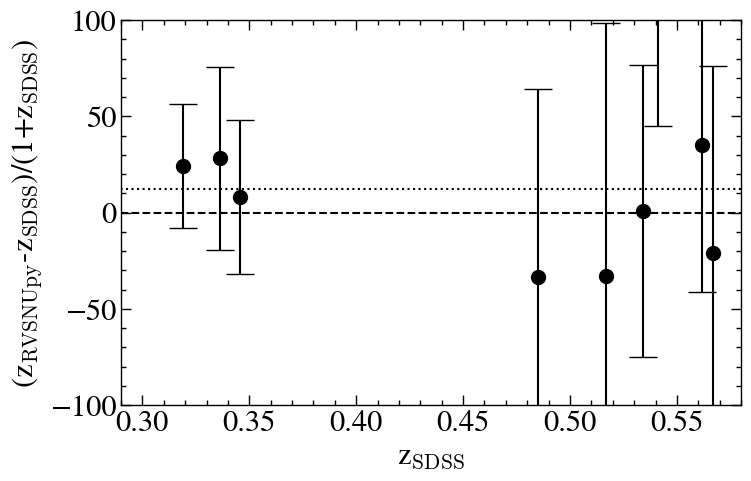

In [15]:
result = multi_rvm(spec_list, sdss_temp_wt_qso, mask=badlines, progress=True)
z_rvsnupy, zerr_rvsnupy = result['Redshift'], result['Error']

from astropy.constants import c
c = c.value/1e+3

f = plt.figure(figsize=(8,5))
ax = f.add_subplot()
ax.errorbar(x=z, y=c*(z_rvsnupy-z)/(1+z), yerr = c*np.sqrt(zerr**2+zerr_rvsnupy**2), fmt='ko', capsize=10, markersize=10)
ax.plot([0,1],[0,0],'k--')
ax.plot([0,1],[12,12],'k:')

ax.set_xlim(0.29,0.58)
ax.set_ylim(-100,100)

ax.set_xlabel(r'z$_{\rm SDSS}$')
ax.set_ylabel(r'(z$_{\rm RVSNUpy}$-z$_{\rm SDSS}$)/(1+z$_{\rm SDSS}$)')

It is known that redshift measured by cross-correlation has an systematic offset from the redshift given by SDSS about 12 km/s.